# Employee Churn Prediction System
## HR Analytics: End-to-End Machine Learning Pipeline

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees, 35 features)
**Goal:** Predict which employees will leave, enabling proactive HR retention interventions.
**random_state = 42** throughout.

## Imports and Settings

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pointbiserialr
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Global settings ──────────────────────────────────────────
RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-pastel')
# sns.set_palette('husl')
FIG_W, FIG_H = 14, 6

In [2]:

plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

---
<a id='section1'></a>
## Section 1 — EDA & Preprocessing

Load the dataset, overview, handling missing values, detect outliers, assess class imbalance, and produce five targeted business visualizations.

### 1.1 — Load Data

In [3]:
RAW_URL = (
    "https://raw.githubusercontent.com/shantanu1109/"
    "IBM-HR-Analytics-Employee-Attrition-and-Performance-Prediction/"
    "main/DATASET/IBM-HR-Analytics-Employee-Attrition-and-Performance-Revised.csv"
)

def load_dataset(url: str) -> pd.DataFrame:
    """Download the IBM HR dataset from GitHub raw URL."""
    df = pd.read_csv(url)
    print(f"✓ Loaded  {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df

df_raw = load_dataset(RAW_URL)
df = df_raw.copy()
df.head()

✓ Loaded  1,470 rows × 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


### 1.2 — Initial Overview

In [4]:
print("=" * 55)
print(f"Shape : {df.shape[0]} rows  ×  {df.shape[1]} columns")
print("=" * 55)

dtype_summary = df.dtypes.value_counts()
print("\nColumn dtypes:")
for dtype, n in dtype_summary.items():
    print(f"  {str(dtype):10s}  {n} columns")

print("\nNumerical summary:")
df.describe().T.style.format("{:.2f}")

Shape : 1470 rows  ×  31 columns

Column dtypes:
  object      16 columns
  int64       15 columns

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Age,1470.00,36.92,9.14,18.00,30.00,36.00,43.00,60.00
DailyRate,1470.00,802.49,403.51,102.00,465.00,802.00,1157.00,1499.00
DistanceFromHome,1470.00,9.19,8.11,1.00,2.00,7.00,14.00,29.00
HourlyRate,1470.00,65.89,20.33,30.00,48.00,66.00,83.75,100.00
MonthlyIncome,1470.00,6502.93,4707.96,1009.00,2911.00,4919.00,8379.00,19999.00
MonthlyRate,1470.00,14313.10,7117.79,2094.00,8047.00,14235.50,20461.50,26999.00
NumCompaniesWorked,1470.00,2.69,2.50,0.00,1.00,2.00,4.00,9.00
PercentSalaryHike,1470.00,15.21,3.66,11.00,12.00,14.00,18.00,25.00
StockOptionLevel,1470.00,0.79,0.85,0.00,0.00,1.00,1.00,3.00
TotalWorkingYears,1470.00,11.28,7.78,0.00,6.00,10.00,15.00,40.00


### 1.3 — Missing Values

**Method & Reasoning:** Compute the count and percentage of nulls per column.
Because the IBM HR dataset is synthetically generated by IBM, it is clean by design, but if nulls were existed in continuous columns, We would impute with the *median* (robust to outliers); for categoricals we would use the *mode*.


In [5]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    """Return a sorted table of missing-value counts and percentages."""
    total = df.isnull().sum()
    pct   = (total / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing': total, 'Pct (%)': pct})
    report = report[report['Missing'] > 0].sort_values('Missing', ascending=False)
    return report

missing = missing_report(df)
if missing.empty:
    print("No missing values found, dataset is complete.")
else:
    print(missing.to_string())

No missing values found, dataset is complete.


### 1.4 — Outlier Detection

We apply two complementary methods:
- **IQR (Tukey fence):** flags values outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR] — robust to non-normal distributions.
- **Z-score (|z| > 3):** appropriate when the column is approximately normal.

Identified outliers are **retained** (not removed) because they represent real employee scenarios (e.g. very high seniority). They are noted for monitoring.

In [6]:
def outlier_count_iqr(series: pd.Series) -> int:
    """Count values outside the Tukey 1.5×IQR fence."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())

def outlier_count_zscore(series: pd.Series, threshold: float = 3.0) -> int:
    """Count values with |z-score| > threshold."""
    z = np.abs(stats.zscore(series.dropna()))
    return int((z > threshold).sum())

num_cols = df.select_dtypes(include=np.number).columns.tolist()

outlier_rows = []
for col in num_cols:
    iqr_n  = outlier_count_iqr(df[col])
    zscore_n = outlier_count_zscore(df[col])
    if iqr_n > 0 or zscore_n > 0:
        outlier_rows.append({
            'Feature': col,
            'IQR Outliers': iqr_n,
            'Z-score Outliers': zscore_n,
        })

outlier_df = pd.DataFrame(outlier_rows).sort_values('IQR Outliers', ascending=False)
print(f"Features with detected outliers: {len(outlier_df)}")
outlier_df.head(15)


Features with detected outliers: 9


,Feature,IQR Outliers,Z-score Outliers
4,TrainingTimesLastYear,238,0
0,MonthlyIncome,114,0
7,YearsSinceLastPromotion,107,42
5,YearsAtCompany,104,25
2,StockOptionLevel,85,0
3,TotalWorkingYears,63,16
1,NumCompaniesWorked,52,0
6,YearsInCurrentRole,21,13
8,YearsWithCurrManager,14,14


### 1.5 — Target Variable Distribution (Attrition)

We encode Attrition as binary (Yes→1, No→0) and measure class imbalance.

A ratio > 4:1 is considered problematic and requires handling.


No  (0):  1233  (83.9%)
Yes (1):   237  (16.1%)
Target ratio: 5.2:1


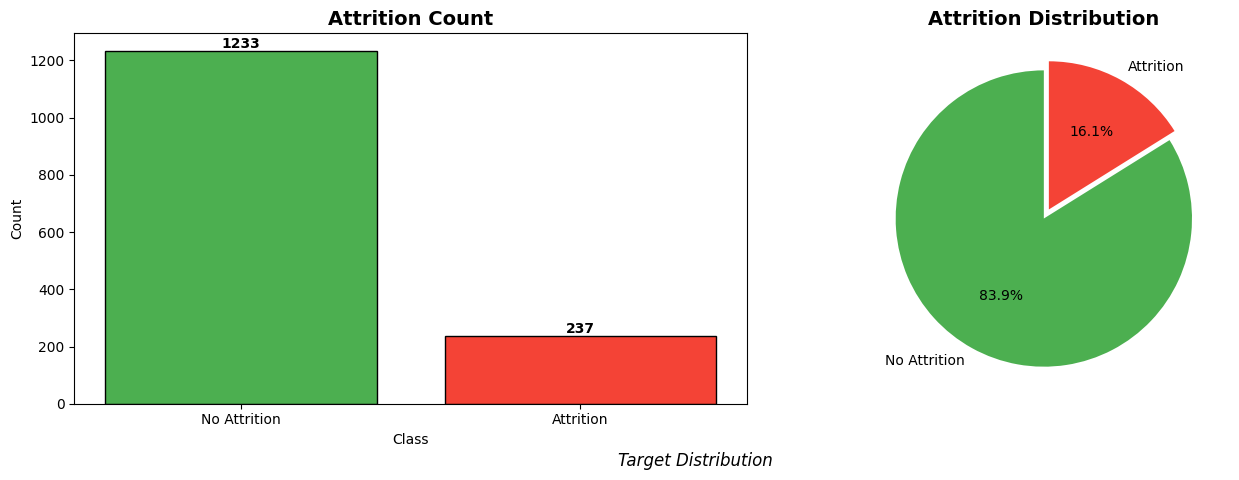

In [9]:
# Encode target
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)
counts = df['Attrition'].value_counts().sort_index()   # sort so 0 is first
pct    = df['Attrition'].value_counts(normalize=True).sort_index() * 100
ratio = counts.iloc[0] / counts.iloc[1]

print(f"No  (0): {counts.iloc[0]:>5}  ({pct.iloc[0]:.1f}%)")
print(f"Yes (1): {counts.iloc[1]:>5}  ({pct.iloc[1]:.1f}%)")
print(f"Target ratio: {ratio:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Count bar
axes[0].bar(['No Attrition', 'Attrition'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_subtitle = None
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')

# Pie
axes[1].pie(counts.values, labels=['No Attrition', 'Attrition'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, explode=[0, 0.07])
axes[1].set_title('Attrition Distribution', fontsize=14, fontweight='bold')

fig.suptitle('Target Distribution',
             fontsize=12, style='italic', y=0.02)
plt.tight_layout()
plt.show()

**Target distribution indicates moderate class imbalance.**

### 1.6 — EDA Visualizations

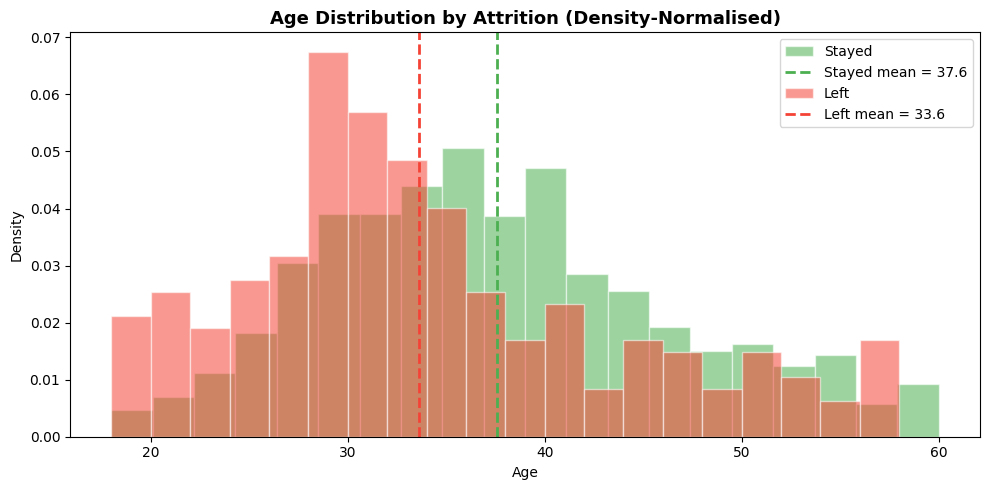

In [20]:
# # ── Viz 1: Age Distribution by Attrition ─────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in [(0, '#4CAF50', 'Stayed'), (1, '#F44336', 'Left')]:
    subset = df[df['Attrition'] == label]['Age']
    ax.hist(subset, bins=20, color=color, edgecolor='white',
            alpha=0.55, label=name, density=True)
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=2,
               label=f'{name} mean = {subset.mean():.1f}')

ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Attrition (Density-Normalised)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

**From the Age distribution we can see that younger employees (25-35) leave more often**

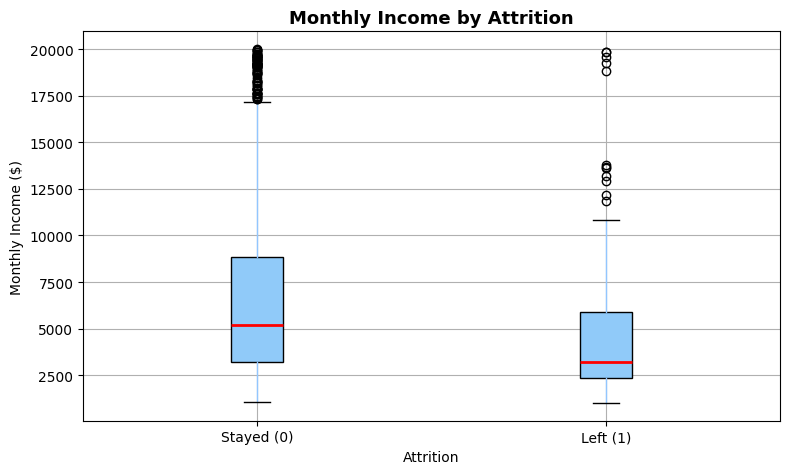

In [19]:
# # ── Viz 2: Monthly Income vs Attrition ───────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column='MonthlyIncome', by='Attrition', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='#90CAF9'),
           medianprops=dict(color='red', linewidth=2))

ax.set_xticklabels(['Stayed (0)', 'Left (1)'])
ax.set_title('Monthly Income by Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Monthly Income ($)')

plt.suptitle('')   # removes the default "Boxplot grouped by Attrition" title pandas adds
plt.tight_layout()
plt.show()

**From the Monthly income vs attrion we can see that employees who leave earn less on average**

Top 15 features correlated with Attrition:
TotalWorkingYears         -0.171
YearsInCurrentRole        -0.161
MonthlyIncome             -0.160
Age                       -0.159
YearsWithCurrManager      -0.156
StockOptionLevel          -0.137
YearsAtCompany            -0.134
DistanceFromHome           0.078
TrainingTimesLastYear     -0.059
DailyRate                 -0.057
NumCompaniesWorked         0.043
YearsSinceLastPromotion   -0.033
MonthlyRate                0.015
PercentSalaryHike         -0.013
HourlyRate                -0.007


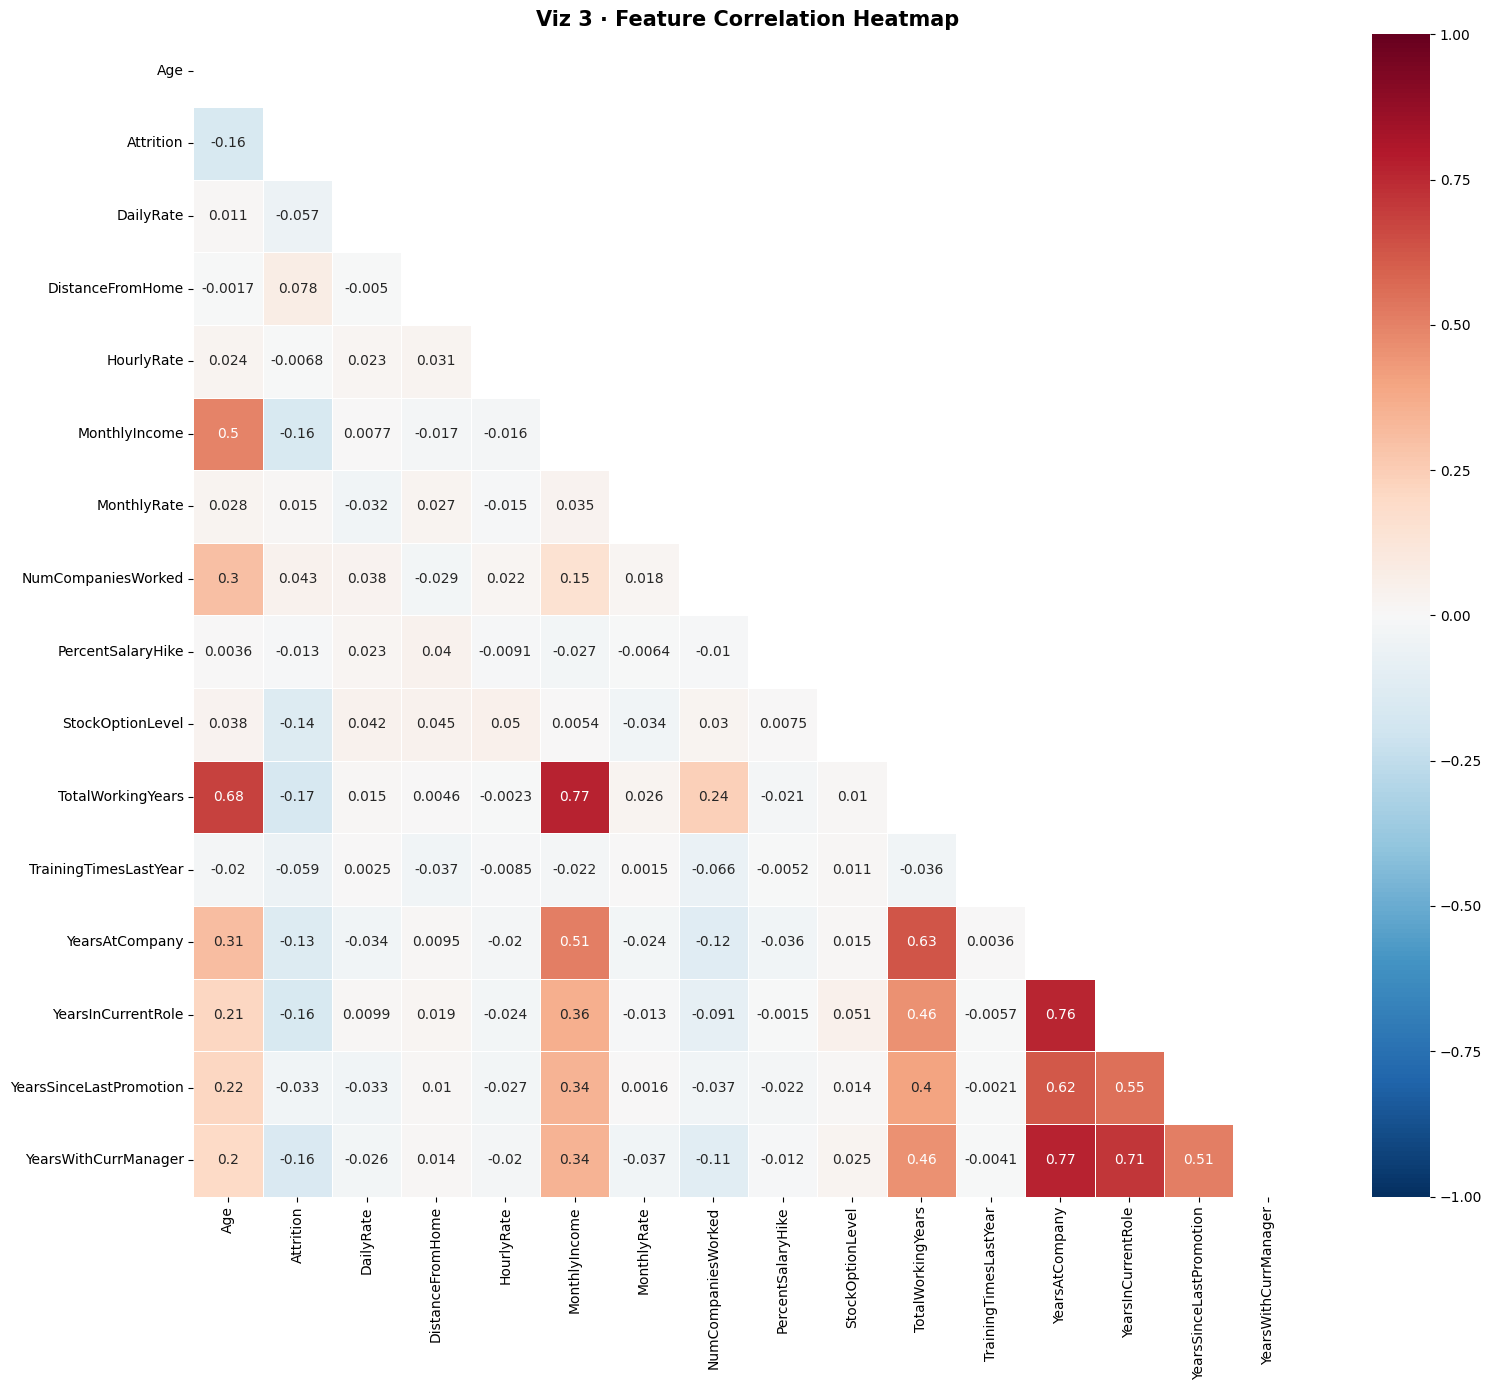

In [24]:
# ── Viz 3: Correlation Heatmap ────────────────────────────────────────────
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

# Highlight top correlations with Attrition
top_corr = (corr['Attrition']
            .drop('Attrition')                                      # exclude self-correlation
            .sort_values(key=lambda s: s.abs(), ascending=False)    # sort by |r|, keep sign
            .head(15))

print("Top 15 features correlated with Attrition:")
print(top_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, linewidths=0.4, ax=ax, vmin=-1, vmax=1)
ax.set_title('Viz 3 · Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**From the strong correlation between TotalWorkingYears, YearsInCurrentRole and MonthlyIncome, we can see that the more years an employee has been with the company and the higher their salary, the less likely they are to leave.**

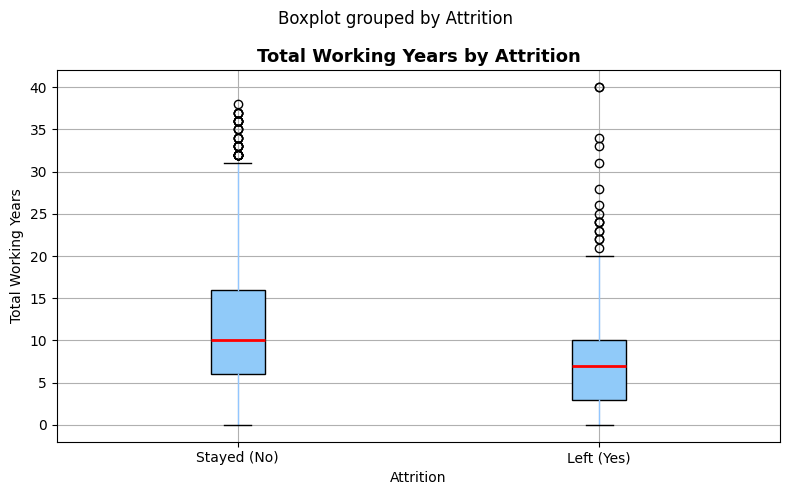

In [ ]:
# ── Viz 4: Total Working Years vs Attrition ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column='TotalWorkingYears', by='Attrition', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='#90CAF9'),
           medianprops=dict(color='red', linewidth=2))

ax.set_xticklabels(['Stayed (No)', 'Left (Yes)'])
ax.set_title('Total Working Years by Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Total Working Years')

plt.tight_layout()
plt.show()

Because TotalWorkingYears showed the highest correlation with the target variable, we display its boxplot as well. We can see that employees who leave tend to have fewer total working years.

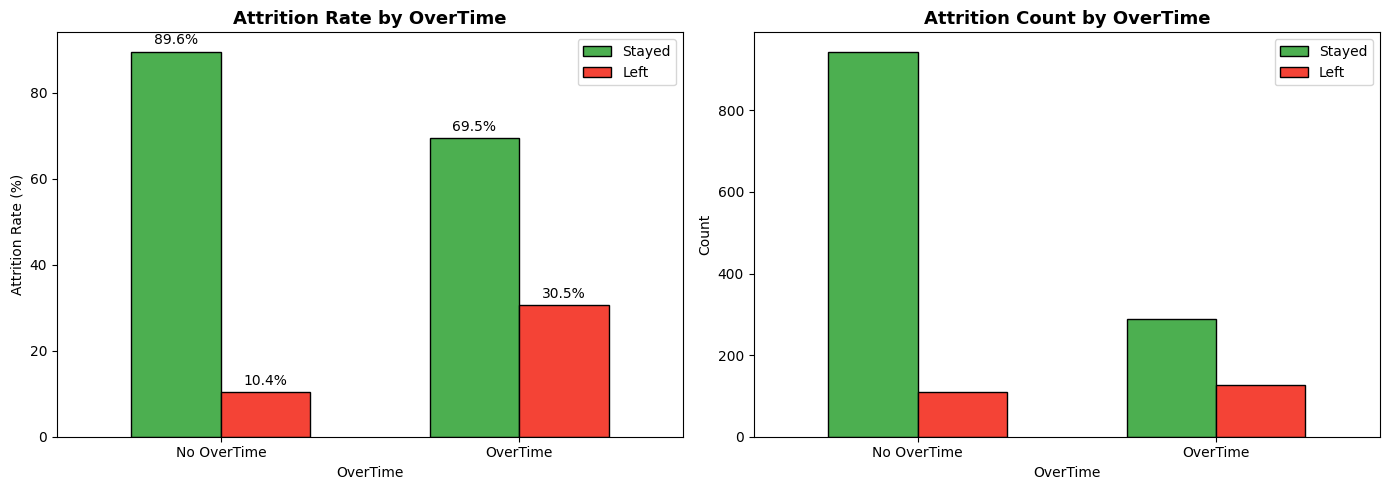

In [ ]:
# ── Viz 5: Overtime vs Attrition ─────────────────────────────────────────
ot_crosstab = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

ot_crosstab.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'],
                 edgecolor='black', width=0.6)
axes[0].set_xlabel('OverTime'); axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by OverTime', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No OverTime', 'OverTime'], rotation=0)
axes[0].legend(['Stayed', 'Left'])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

# Raw counts
ot_counts = pd.crosstab(df['OverTime'], df['Attrition'])
ot_counts.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'],
               edgecolor='black', width=0.6)
axes[1].set_xlabel('OverTime'); axes[1].set_ylabel('Count')
axes[1].set_title('Attrition Count by OverTime', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['No OverTime', 'OverTime'], rotation=0)
axes[1].legend(['Stayed', 'Left'])

plt.tight_layout()
plt.show()

**Employees who work more overtime are more likely to leave**

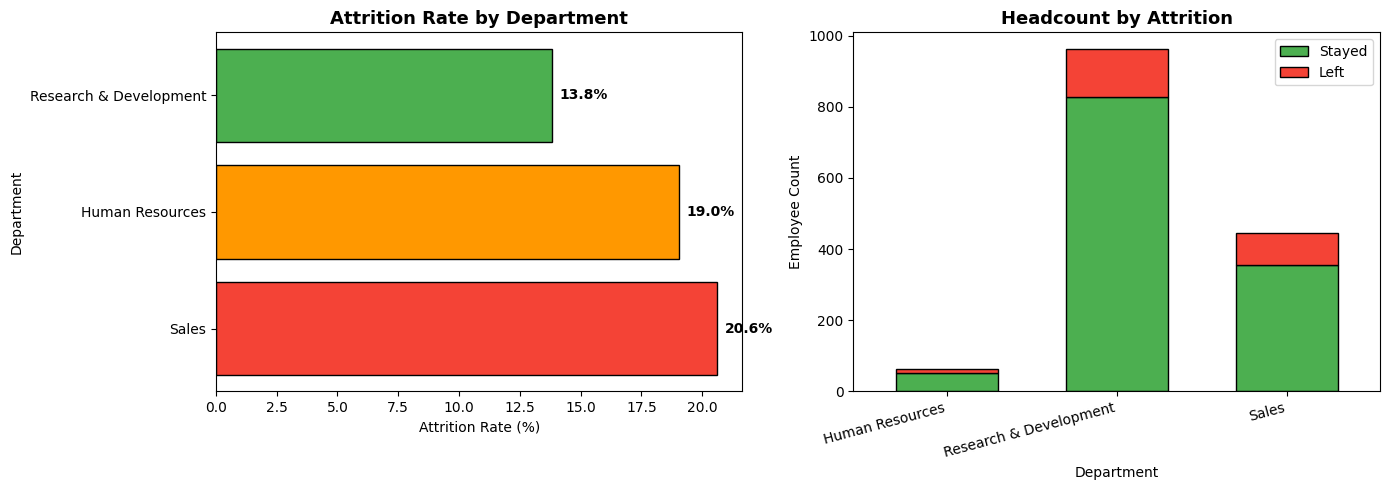

In [ ]:
# ── Viz 6: Department vs Attrition Rate ──────────────────────────────────
dept_rate = (df.groupby('Department')['Attrition']
               .agg(['mean', 'sum', 'count'])
               .rename(columns={'mean': 'Rate', 'sum': 'Churned', 'count': 'Total'}))
dept_rate['Rate'] = dept_rate['Rate'] * 100
dept_rate = dept_rate.sort_values('Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

bars = axes[0].barh(dept_rate.index, dept_rate['Rate'],
                    color=['#F44336', '#FF9800', '#4CAF50'], edgecolor='black')
axes[0].set_xlabel('Attrition Rate (%)'); axes[0].set_ylabel('Department')
axes[0].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
for bar, rate in zip(bars, dept_rate['Rate']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%', va='center', fontweight='bold')

# Stacked bar
dept_abs = pd.crosstab(df['Department'], df['Attrition'])
dept_abs.columns = ['Stayed', 'Left']
dept_abs.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#4CAF50', '#F44336'], edgecolor='black', width=0.6)
axes[1].set_xlabel('Department'); axes[1].set_ylabel('Employee Count')
axes[1].set_title('Headcount by Attrition', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

**Sales has the highest rate of attrition(~21%), R&D has the lowest rate (~14%).**

### 1.7 — Statistical Analysis by Attrition Class

In [44]:
# Keep only columns that are actually numeric in the dataframe
key_num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'Attrition']

stat_table = (df.groupby('Attrition')[key_num_cols]
                .agg(['mean', 'median', 'std'])
                .round(2)
                .T
                .rename(columns={0: 'No', 1: 'Yes'}, level=0))
stat_table

Attrition                             No       Yes
Age                     mean       37.56     33.61
                        median     36.00     32.00
                        std         8.89      9.69
DailyRate               mean      812.50    750.36
                        median    817.00    699.00
                        std       403.21    401.90
DistanceFromHome        mean        8.92     10.63
                        median      7.00      9.00
                        std         8.01      8.45
HourlyRate              mean       65.95     65.57
                        median     66.00     66.00
                        std        20.38     20.10
MonthlyIncome           mean     6832.74   4787.09
                        median   5204.00   3202.00
                        std      4818.21   3640.21
MonthlyRate             mean    14265.78  14559.31
                        median  14120.00  14618.00
                        std      7102.26   7208.15
NumCompaniesWorked      mean        2.65      2.94
                        median      2.00      1.00
                        std         2.46      2.68
PercentSalaryHike       mean       15.23     15.10
                        median     14.00     14.00
                        std         3.64      3.77
StockOptionLevel        mean        0.85      0.53
                        median      1.00      0.00
                        std         0.84      0.86
TotalWorkingYears       mean       11.86      8.24
                        median     10.00      7.00
                        std         7.76      7.17
TrainingTimesLastYear   mean        2.83      2.62
                        median      3.00      2.00
                        std         1.29      1.25
YearsAtCompany          mean        7.37      5.13
                        median      6.00      3.00
                        std         6.10      5.95
YearsInCurrentRole      mean        4.48      2.90
                        median      3.00      2.00
                        std         3.65      3.17
YearsSinceLastPromotion mean        2.23      1.95
                        median      1.00      1.00
                        std         3.23      3.15
YearsWithCurrManager    mean        4.37      2.85
                        median      3.00      2.00
                        std         3.59      3.14